🎯 **You Sank My Function** — Black-Box Optimisation Capstone · Imperial College Business School

**Pipeline (B)** · [04 Consolidate](../pipeline/04_consolidate_data.ipynb) → [06 Diagnose](../pipeline/06_diagnose.ipynb) → [05 Suggest engine](../pipeline/05_suggest_engine.ipynb) · [07 Run week + report](../pipeline/07_run_week_and_report.ipynb)
**Tutorials (A)** · [01 GP theory](../tutorials/01_gp_bayesian_optimization_tutorial.ipynb) · [02 Acquisition engine](../tutorials/02_gp_suggest_input_tutorial.ipynb) · [03 EDA & prototype](../tutorials/03_capstone_eda_and_prototype.ipynb)
**Diagnostics (C)** · [A1 SVM](../diagnostics/A1_svm_analysis.ipynb) · [A2 Logistic regression](../diagnostics/A2_logistic_regression.ipynb) · [A3 Landscape gallery](../diagnostics/A3_landscape_gallery.ipynb)
**Neural + LLM (D)** · [08 NN (educational)](../neural/08_neural_surrogates_edu.ipynb) · [09 NN for F6](../neural/09_neural_surrogates_F6.ipynb) · [10 NN engine](../neural/10_neural_surrogates_engine.ipynb)

> 📍 **This notebook** — **Weekly runner + report (B). Runs 04 → 06 → 05 in order, audits and surfaces the submission, then renders the three assessment figures.**

---

# 07 · Weekly Runner + Report — *You Sank My Function*
### One command for the whole weekly loop

**Purpose.** Turn the four-step weekly dance — *consolidate → diagnose → update →
suggest* — into a single top-to-bottom run with a fixed, correct order and one
consolidated dashboard at the end.

**What it does each week**

1. **Pre-flight** — checks the notebooks are present and that the cumulative
   weekly files have matching week-row counts (catches the classic *appended the
   input but not the output*).
2. **Runs `04 → 06 → 05` in order** — consolidate the data, re-audit each
   method against the fresh evidence, then regenerate the suggestion. A broken
   step **fails loudly** rather than leaving a stale suggestion in place.
3. **Dashboard** — running-best per function, the per-function summary, the
   diagnostic audit, and any 🚩 *redirect* flags, all in one view.
4. **Suggestion** — surfaces the official portal string produced by `05`.

> ### Design rule: pure orchestration
> This notebook runs the *real* `04`/`05`/`06` and reads their file outputs. It
> deliberately holds **no per-function metadata of its own** — no dims, no
> hypotheses, no methods — so it can never become a fourth copy that drifts from
> the others. The single source of truth stays in `05`'s `RECORDS`.

---

## 0 · Configuration

In [1]:
# Pure orchestration: RUN the notebooks, READ their outputs. No logic is
# re-implemented here, by design.
import os, sys, json, time, subprocess, importlib.util
from pathlib import Path
import numpy as np, pandas as pd

KERNEL     = "python3"
NB_TIMEOUT = 1800            # seconds allowed per notebook

def _find_pipeline_dir():
    """Locate the folder holding 04/05/06 (works from repo root or pipeline/)."""
    here = Path.cwd()
    candidates = [here, here / "pipeline", here.parent / "pipeline"]
    for cand in candidates:
        if (cand / "04_consolidate_data.ipynb").exists():
            return cand.resolve()
    return here.resolve()

PIPELINE_DIR = (Path(os.environ["BBO_PIPELINE_DIR"]).resolve()
                if os.environ.get("BBO_PIPELINE_DIR") else _find_pipeline_dir())

NB = {
    "04": PIPELINE_DIR / "04_consolidate_data.ipynb",
    "05": PIPELINE_DIR / "05_suggest_engine_v2.ipynb",
    "06": PIPELINE_DIR / "06_diagnose.ipynb",
}
RUN_ORDER = ["04", "06", "05"]     # consolidate -> diagnose/audit -> suggest

# Files the pipeline writes next to the notebooks (those notebooks use OUT_DIR=".")
CSV_OBS         = PIPELINE_DIR / "consolidated_observations.csv"
CSV_SUMMARY     = PIPELINE_DIR / "function_summary.csv"
CSV_DIAGNOSE    = PIPELINE_DIR / "diagnosis_report.csv"
SUBMISSION_FILE = PIPELINE_DIR / "submission.txt"   # used only if 05 writes one

# Cumulative weekly files — set BBO_DATA_DIR so this runner and 04 agree.
DATA_DIR = Path(os.environ.get("BBO_DATA_DIR", PIPELINE_DIR.parent / "data"))

print("pipeline dir :", PIPELINE_DIR)
for k in RUN_ORDER:
    print(f"  notebook {k} : {'found ' if NB[k].exists() else 'MISSING'} · {NB[k].name}")
print("data dir     :", DATA_DIR,
      "(exists)" if DATA_DIR.exists() else "(not found here — 04 will resolve its own path)")

pipeline dir : C:\Users\USER
  notebook 04 : found  · 04_consolidate_data.ipynb
  notebook 06 : found  · 06_diagnose.ipynb
  notebook 05 : found  · 05_suggest_engine_v2.ipynb
data dir     : C:\Users\data (not found here — 04 will resolve its own path)


## 1 · Pre-flight checks

Cheap checks that catch the failure modes of the one manual step (appending the
new week's row) *before* spending time executing anything. Deep validation —
8 functions per row, correct dimensionality — is **delegated to 04**, which
already asserts it, so this stays a thin guard rather than a second parser.

In [2]:
problems = [f"notebook {k} not found at {NB[k]}" for k in RUN_ORDER if not NB[k].exists()]

def _find_weekly():
    name_pairs = [("inputs.txt", "outputs.txt"),
                  ("weekly_inputs.txt", "weekly_outputs.txt")]
    dirs = [DATA_DIR, PIPELINE_DIR.parent / "data", PIPELINE_DIR]
    for d in dirs:
        for ni, no in name_pairs:
            if (Path(d) / ni).exists() and (Path(d) / no).exists():
                return Path(d) / ni, Path(d) / no
    return None, None

fin, fout = _find_weekly()
if fin is None:
    print("⚠️  Could not locate the weekly input/output files from here.")
    print("    Set BBO_DATA_DIR so this runner and 04 agree (04 still resolves its own path).")
else:
    nlines = lambda p: sum(1 for ln in open(p, encoding="utf-8") if ln.strip())
    ni, no = nlines(fin), nlines(fout)
    print(f"weekly inputs : {fin}  ({ni} week-rows)")
    print(f"weekly outputs: {fout}  ({no} week-rows)")
    if ni != no:
        problems.append(f"week-row count mismatch: {ni} inputs vs {no} outputs "
                        "(appended one file but not the other?)")

if problems:
    raise RuntimeError("Pre-flight failed:\n  - " + "\n  - ".join(problems))
print("\n✅ Pre-flight OK — deep validation (dims, 8 functions/row) is delegated to 04.")

weekly inputs : C:\Users\USER\inputs.txt  (11 week-rows)
weekly outputs: C:\Users\USER\outputs.txt  (11 week-rows)

✅ Pre-flight OK — deep validation (dims, 8 functions/row) is delegated to 04.


## 2 · Run the pipeline — 04 → 06 → 05

Executes each notebook **in place** (refreshing its saved outputs, exactly as a
manual re-run would) using `papermill` if available, falling back to
`jupyter nbconvert`. The order is fixed: consolidate the data, then re-audit the
methods against it, then regenerate the suggestion. Any failing step raises —
a bad run can't silently leave last week's suggestion standing.

In [3]:
def _have(mod):
    return importlib.util.find_spec(mod) is not None

def run_notebook(path, timeout=NB_TIMEOUT):
    path = Path(path)
    if _have("papermill"):
        import papermill as pm
        pm.execute_notebook(str(path), str(path), kernel_name=KERNEL,
                            progress_bar=False, cwd=str(path.parent))
        return "papermill"
    cmd = [sys.executable, "-m", "jupyter", "nbconvert", "--to", "notebook",
           "--execute", "--inplace",
           f"--ExecutePreprocessor.timeout={timeout}",
           f"--ExecutePreprocessor.kernel_name={KERNEL}", str(path)]
    res = subprocess.run(cmd, capture_output=True, text=True, cwd=str(path.parent))
    if res.returncode != 0:
        raise RuntimeError(f"Execution failed on {path.name}:\n{res.stderr[-3000:]}")
    return "nbconvert"

for k in RUN_ORDER:
    t0 = time.time()
    engine = run_notebook(NB[k])
    print(f"  ✓ ran {NB[k].name:<28} via {engine}  ({time.time() - t0:0.1f}s)")
print("\n✅ Pipeline complete — 04 → 06 → 05.")

  ✓ ran 04_consolidate_data.ipynb    via nbconvert  (11.7s)
  ✓ ran 06_diagnose.ipynb            via nbconvert  (19.8s)
  ✓ ran 05_suggest_engine_v2.ipynb   via nbconvert  (16.8s)

✅ Pipeline complete — 04 → 06 → 05.


## 3 · Dashboard — state, audit, and redirects

Reads back the files the pipeline just wrote and shows, in one place: the
running-best per function, the per-function summary, the diagnostic audit, and
— loudest of all — any function whose method the data no longer supports.

In [4]:
try:
    from IPython.display import display
except Exception:
    display = print

obs     = pd.read_csv(CSV_OBS)
summary = pd.read_csv(CSV_SUMMARY)  if CSV_SUMMARY.exists()  else None
diag    = pd.read_csv(CSV_DIAGNOSE) if CSV_DIAGNOSE.exists() else None

n_weeks = int(obs["week"].max())
print(f"State after Week {n_weeks}  ·  {len(obs)} observations · {obs['function'].nunique()} functions\n")

print("Running best (cumulative max up to each week):")
for f in sorted(obs["function"].unique()):
    s = obs[obs.function == f].groupby("week").y.max().sort_index().cummax()
    print(f"  F{f}: " + "  ".join(f"W{w}={v:.4g}" for w, v in s.items()))

if summary is not None:
    print("\nPer-function summary:")
    display(summary)

if diag is not None:
    print("\nDiagnostic audit (06):")
    display(diag)
    rcol = next((c for c in diag.columns if "redirect" in c.lower()), None)
    if rcol is not None:
        flagged = diag[diag[rcol].astype(str).str.upper().str.contains("YES")]
        if len(flagged):
            print("\n🚩 REDIRECTS — the data no longer supports the method in use:")
            display(flagged)
        else:
            print("\n✅ No redirects — every method still supported by the evidence.")

State after Week 13  ·  279 observations · 8 functions

Running best (cumulative max up to each week):
  F1: W0=7.711e-16  W1=7.711e-16  W2=2.675e-09  W3=0.1575  W4=0.1575  W5=0.9289  W6=0.9289  W7=0.9289  W8=1.23  W9=1.525  W10=2  W11=2  W12=2  W13=2
  F2: W0=0.6112  W1=0.6112  W2=0.6112  W3=0.6112  W4=0.6112  W5=0.6112  W6=0.6112  W7=0.6112  W8=0.6112  W9=0.6153  W10=0.6505  W11=0.6505  W12=0.6505  W13=0.6505
  F3: W0=-0.03484  W1=-0.02492  W2=-0.02492  W3=-0.02492  W4=-0.02492  W5=-0.02492  W6=-0.02492  W7=-0.02492  W8=-0.02492  W9=-0.02404  W10=-0.01507  W11=-0.01507  W12=-0.0003699  W13=-0.0003699
  F4: W0=-4.026  W1=-3.986  W2=-3.986  W3=0.3655  W4=0.3655  W5=0.3655  W6=0.5012  W7=0.5969  W8=0.5969  W9=0.5969  W10=0.6401  W11=0.6401  W12=0.6401  W13=0.6549
  F5: W0=1089  W1=1089  W2=2428  W3=2428  W4=3126  W5=3416  W6=4441  W7=4441  W8=4441  W9=8662  W10=8662  W11=8662  W12=8662  W13=8662
  F6: W0=-0.7143  W1=-0.7143  W2=-0.7143  W3=-0.2669  W4=-0.2669  W5=-0.2669  W6=-0.2669  W7

,function,dim,n_obs,status,init_best,overall_best,improved_vs_init,best_from_week,best_x
0,F1,2,23,signal_found,0.000000,1.999950,yes,11,"[0.628468, 0.628468]"
1,F2,2,23,uncertain,0.611205,0.650484,yes,10,"[0.6854, 0.3325]"
2,F3,3,28,near_ceiling,-0.034835,-0.000370,yes,12,"[0.4, 0.52, 0.45]"
3,F4,4,43,modelled,-4.025542,0.654868,yes,13,"[0.427, 0.4112, 0.3533, 0.4101]"
4,F5,4,33,modelled,1088.859618,8662.482500,yes,9,"[1.0, 1.0, 1.0, 1.0]"
5,F6,5,33,modelled,-0.714265,-0.234747,yes,10,"[0.35, 0.44, 0.66, 0.71, 0.0]"
6,F7,6,43,solved,1.364968,3.322368,yes,10,"[0.201689, 0.150011, 0.476874, 0.275332, 0.311..."
7,F8,8,53,solved,9.598482,10.000000,yes,2,"[0.1, 0.15, 0.13, 0.15, 0.8, 0.5, 0.2, 0.6]"



Diagnostic audit (06):


,F,recommended,confidence,redirect?,regime,directions,current_method
0,F1,INSUFFICIENT EVIDENCE — explore / keep current...,low,NaN,noise-free,x1↑ x2·,source localisation (ZoMBI/inversion)
1,F2,GP-BO (EI; mean-exploitation if huge range; re...,low,NaN,noisy,x1↑ x2·,manual ridge inference
2,F3,benchmark refuted -> structural/BO fallback,low,YES,noisy,x1· x2· x3·,exploit benchmark point (identity unconfirmed)
3,F4,GP-BO (EI; mean-exploitation if huge range; re...,medium,NaN,noise-free,x1↓ x2↓ x3· x4↓,GP-BO (EI)
4,F5,GP-BO (EI; mean-exploitation if huge range; re...,medium,NaN,noise-free,x1· x2↑ x3↑ x4↑,log-GP posterior-mean
5,F6,GP-BO (EI; mean-exploitation if huge range; re...,medium,NaN,noisy,x1· x2· x3↑ x4↑ x5↓,separable polynomial inversion
6,F7,analytic solve (hartmann6 confirmed),high,NaN,noise-free,x1↓ x2↓ x3· x4· x5↓ x6↑,analytic solve (Hartmann-6D)
7,F8,separable inversion (per-dim analytic optima),high,NaN,noise-free,x1↓ x2↓ x3↓ x4↓ x5↑ x6· x7↓ x8·,analytic solve (quadratic)



🚩 REDIRECTS — the data no longer supports the method in use:


,F,recommended,confidence,redirect?,regime,directions,current_method
2,F3,benchmark refuted -> structural/BO fallback,low,YES,noisy,x1· x2· x3·,exploit benchmark point (identity unconfirmed)


## 4 · This week's suggestion (the portal string)

Surfaces the official string produced by `05`. If `05` writes a `submission.txt`
this reads it directly; otherwise it scrapes `05`'s executed output for the most
likely line.

> **Tip.** Have `05` write its portal string to `submission.txt` (one line) to
> make this section fully deterministic instead of best-effort scraping.

In [5]:
def scrape_text_outputs(nb_path):
    nb = json.load(open(nb_path, encoding="utf-8"))
    chunks = []
    for c in nb.get("cells", []):
        if c.get("cell_type") != "code":
            continue
        for o in c.get("outputs", []):
            if o.get("output_type") == "stream":
                chunks.append("".join(o.get("text", [])))
            elif o.get("output_type") in ("execute_result", "display_data"):
                t = o.get("data", {}).get("text/plain")
                if t:
                    chunks.append("".join(t))
    return "\n".join(chunks)

printed = False
if SUBMISSION_FILE.exists():
    print("Submission (from submission.txt):\n")
    print("   " + SUBMISSION_FILE.read_text().strip())
    printed = True
else:
    lines = [ln for ln in scrape_text_outputs(NB["05"]).splitlines() if ln.strip()]
    keys  = ("submit", "portal", "suggest", "string")
    hits  = [ln for ln in lines if any(k in ln.lower() for k in keys)]
    if hits:
        print("Likely submission line(s) from 05's output:\n")
        for ln in hits[-8:]:
            print("   " + ln.strip())
        printed = True
    elif lines:
        print("Tail of 05's executed output (locate your portal string):\n")
        for ln in lines[-12:]:
            print("   " + ln.strip())
        printed = True

if not printed:
    print("Could not auto-locate the suggestion. Open 05_suggest_engine.ipynb and read its "
          f"final cell, or have 05 write '{SUBMISSION_FILE.name}' for a deterministic read.")

Likely submission line(s) from 05's output:

   Loaded 279 observations · weeks 0–13 · suggesting for week 14
   Weekly loop: submit -> append returned rows -> re-run 04 then this notebook.


## 5 · The weekly loop, now one notebook

When Week-N results come back:

1. Append **one** row to `inputs.txt` and `outputs.txt` — the only manual step.
2. Run this notebook top to bottom.
3. Read the dashboard: accept any 🚩 redirect, or override it deliberately.
4. Submit the portal string from §4.

Everything between 1 and 4 — consolidation, the integrity audit, the diagnostic
re-check, and regenerating the suggestion — now runs automatically in the correct
order. The *judgment* calls (accept a redirect? deprioritise a stalled function?)
are surfaced explicitly; the mechanical work is no longer yours to remember.

**Next step (separate change).** Promote `05`'s `RECORDS` to a shared
`records.json` that `04` and `06` read from. After that, the per-function
metadata lives in exactly one place and the weekly edit drops from three files to
one — eliminating the drift this set has already been bitten by twice.

---
## Part B · Report figures

The second half reads the consolidated table the pipeline just wrote and renders the three assessment figures (Output progression, Ranking evolution, Decision dashboard). It re-imports its own dependencies so this section can also be run on its own. Point the figures' save path at `../report/figures/` to refresh the committed PNGs.

# 📊 BBO Weekly Report Figures  ·  v2

**Phase 1b of the *You Sank My Function* pipeline** — turns the consolidated
observation table from `04_consolidate_data.ipynb` into three presentation-ready
report figures:

| Figure | What it shows |
|---|---|
| **Figure 1** | Function output progression (per-week values, change, trend, next-round strategy) |
| **Figure 14** | Function ranking evolution — ranked by **gain over each function's pre-query baseline** |
| **Figure 7** | Decision dashboard — performance summary, decision-matrix scatter, key insights, priority ranking, strategy |

### What changed in v2
1. **Fair ranking.** Ranking no longer uses raw output, which let F5 top the
   list purely because its Y-scale (~2800) dwarfs the others. It now ranks by
   **improvement over the Week-0 baseline** (`init_best`, the maximum *before*
   any weekly query). A high-value-but-stagnant function (e.g. F8) correctly
   drops; a small-scale function that genuinely improved (e.g. F1) rises.
   Switch behaviour with `RANK_METRIC` (`rel_improvement` | `abs_improvement` | `raw`).
2. **Any number of rounds.** Works for the full 13-week season. `N_WEEKS_SHOWN`
   sets how many recent rounds the tables display; every title (`Weeks a–b`,
   `Week N+1 Priorities`) is derived from the data.

### How it connects to your pipeline
Reads **`consolidated_observations.csv`**. Per function it uses the per-week
query value (`y` at `week == w`) for the progression, and the **Week-0 maximum**
(`y` at `week == 0`) as the baseline for ranking. If the CSV is absent it runs
on built-in **sample data**.

> The *confidence* column is curated (it can't be derived from outputs alone), so
> it is mapped from each function's Phase-2 `status` via `STATUS_CONFIDENCE`;
> override per function with `CONFIDENCE_OVERRIDE`.

## 1 · Imports

In [6]:
import os
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, FancyArrow
import matplotlib.gridspec as gridspec

## 2 · Configuration

Key knobs: **`N_WEEKS_SHOWN`** (recent rounds to display) and **`RANK_METRIC`** (how Figure 14 ranks). `SAMPLE_*` are only used if the CSV is missing.

In [7]:
# ───────────────────────── CONFIG ─────────────────────────
CSV_PATH = os.environ.get("BBO_CONSOLIDATED_CSV", "consolidated_observations.csv")
OUT_DIR  = "."
N_WEEKS_SHOWN = 3      # how many recent weekly rounds the tables show (3–5 is readable)

# Performance-ranking metric (Figure 14 + the dashboard "vs Init" column):
#   "rel_improvement" → % gain of running-best over the Week-0 baseline (default; scale-fair)
#   "abs_improvement" → absolute gain of running-best over the Week-0 baseline
#   "raw"             → that week's raw output (original behaviour; F5 dominates)
RANK_METRIC = "rel_improvement"

FUNCTION_META = {
    1: dict(dim=2, status="signal_found"),
    2: dict(dim=2, status="uncertain"),
    3: dict(dim=3, status="near_ceiling"),
    4: dict(dim=4, status="modelled"),
    5: dict(dim=4, status="modelled"),
    6: dict(dim=5, status="modelled"),
    7: dict(dim=6, status="solved"),
    8: dict(dim=8, status="solved"),
}

STATUS_CONFIDENCE = {
    "solved": 0.90, "near_ceiling": 0.75, "modelled": 0.55,
    "signal_found": 0.45, "uncertain": 0.30,
}
CONFIDENCE_OVERRIDE = {}     # e.g. {5: 0.40, 8: 0.85}

# Sample data so the notebook runs before the real CSV exists.
SAMPLE_WEEKLY = {
    1: [0.000000, 0.000000, 0.025559],
    2: [0.454942, 0.412137, 0.140988],
    3: [-0.101836, -0.133256, -0.127870],
    4: [-4.359875, -23.120154, -14.554029],
    5: [1415.876000, 2308.149000, 2840.990000],
    6: [-0.700155, -2.070246, -0.648848],
    7: [1.319994, 1.069658, 0.896603],
    8: [9.580240, 9.524100, 9.442960],
}
# Pre-query (Week-0) best per function for sample mode. The real value comes
# from the consolidated CSV (max y at week == 0).
SAMPLE_INITIAL = {1: 0.0, 2: 0.500, 3: -0.100, 4: -4.000,
                  5: 1088.860, 6: -0.700, 7: 1.350, 8: 9.600}

# Estimated true max ("ceiling") per function — drives the Figure B4 normalised score:
#   score = (best_ever - Week-0 baseline) / (ceiling - Week-0 baseline), clipped to [0,1].
#   lo/hi = the ceiling's plausible range -> the uncertainty whisker; conf is a label.
#   F7, F8 are solved (ceiling = known true max). F5's ceiling is the least certain.
#   F2: best == baseline (no gain) and the noiseless max (~0.60) sits at/under that
#       baseline, so the ceiling is pinned at 0.70 ("draws-to") to keep the score
#       well-defined (it evaluates to 0 either way).
CEILINGS = {
    1: dict(c=1.00,   lo=0.93,   hi=1.00,   conf="med"),
    2: dict(c=0.70,   lo=0.60,   hi=0.70,   conf="low"),
    3: dict(c=0.00,   lo=-0.02,  hi=0.00,   conf="low"),
    4: dict(c=0.68,   lo=0.50,   hi=0.75,   conf="med-low"),
    5: dict(c=5000.0, lo=4000.0, hi=6000.0, conf="low"),
    6: dict(c=-0.20,  lo=-0.25,  hi=-0.15,  conf="low"),
    7: dict(c=3.3224, lo=3.3224, hi=3.3224, conf="high"),   # solved
    8: dict(c=10.000, lo=10.000, hi=10.000, conf="high"),   # solved
}


## 3 · Palette & style

In [8]:
# ───────────────────────── PALETTE ─────────────────────────
NAVY = "#1c3a5e"; NAVY2 = "#21527d"; GREEN = "#1e8449"; RED = "#c0392b"
PURPLE = "#6c3483"; ORANGE = "#ca7a10"; GREY = "#566573"; INK = "#1b2631"
GREEN_T = "#e8f6ee"; PURPLE_T = "#f0eaf6"; RED_T = "#fbeceb"; BLUE_T = "#eaf1f8"
GOLD = "#f1c40f"; SILVER = "#b3b6b7"; BRONZE = "#cd7f32"
PANEL_COLORS = [NAVY, GREEN, PURPLE, "#117a8b", "#a04000", "#5b2c6f"]

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.edgecolor": "#d5dbdb",
    "figure.dpi": 110,
})

# ── per-function colours + infographic theme (Figures B4–B5) ──
FUNCTION_COLORS = {1:"#16a0a0", 2:"#8e44ad", 3:"#e84b7c", 4:"#1f3a93",
                   5:"#ed7d1c", 6:"#8c5a2b", 7:"#5ba82e", 8:"#2e6cc4"}
INFO_NAVY="#0d1b3e"; INFO_EDGE="#cfe0f5"; INFO_GREEN="#1f7a3d"; INFO_BLUE="#13357a"
MUTED="#6b7a90"; TRACK="#eef2f8"
STATUS_SHORT={"solved":"solved","near_ceiling":"ceiling","modelled":"modelled",
              "signal_found":"signal","uncertain":"uncertain"}


## 4 · Data layer

Loads weekly outputs **and the Week-0 baseline** per function; derives change, trend, confidence, gain-over-baseline, quadrant and priority. `rank_for_week` produces the fair performance ranking used by Figure 14.

In [9]:
# ───────────────────────── DATA LAYER ─────────────────────────
def load_weekly_outputs():
    """Return (weekly, init_best, source_str).

    weekly:    {function: [w1, w2, ...]}  per-week query values (week >= 1)
    init_best: {function: pre-query Week-0 maximum}
    Falls back to SAMPLE_* if the consolidated CSV is absent.
    """
    if os.path.exists(CSV_PATH):
        df = pd.read_csv(CSV_PATH)
        weekly, init_best = {}, {}
        for f in range(1, 9):
            sub = df[df["function"] == f]
            wk = sub[sub["week"] >= 1].sort_values("week")
            weekly[f] = wk["y"].tolist()
            wk0 = sub[sub["week"] == 0]["y"]
            init_best[f] = float(wk0.max()) if len(wk0) else (
                float(weekly[f][0]) if weekly[f] else float("nan"))
        src = f"loaded from {CSV_PATH}"
    else:
        weekly = {f: list(v) for f, v in SAMPLE_WEEKLY.items()}
        init_best = dict(SAMPLE_INITIAL)
        src = "SAMPLE data (consolidated CSV not found)"
    return weekly, init_best, src


def n_total_weeks(weekly):
    return max((len(v) for v in weekly.values()), default=0)


def shown_weeks(weekly, n=None):
    """The list of (1-indexed) week numbers the tables display (most recent n)."""
    if n is None:
        n = N_WEEKS_SHOWN
    tot = n_total_weeks(weekly)
    start = max(1, tot - n + 1)
    return list(range(start, tot + 1))


def next_week_label(weekly):
    return f"Week {n_total_weeks(weekly) + 1}"


def confidence_for(f):
    if f in CONFIDENCE_OVERRIDE:
        return CONFIDENCE_OVERRIDE[f]
    return STATUS_CONFIDENCE.get(FUNCTION_META[f]["status"], 0.5)


def trend_symbol(series, rel_deadband=0.01):
    if len(series) < 2:
        return "→", GREY
    step = series[-1] - series[-2]
    scale = abs(series[-1]) + abs(series[-2]) + 1e-9
    if abs(step) / scale < rel_deadband:
        return "→", ORANGE
    return ("↑", GREEN) if step > 0 else ("↓", RED)


def running_best_upto(weekly, init_best, f, week):
    """Best y for function f over Week-0 baseline + weekly queries up to `week`."""
    vals = [init_best[f]] + list(weekly[f][:week])
    vals = [v for v in vals if not (isinstance(v, float) and np.isnan(v))]
    return max(vals) if vals else float("nan")


def _obs_range(weekly, init_best, f):
    obs = [init_best[f]] + list(weekly[f])
    obs = [v for v in obs if not (isinstance(v, float) and np.isnan(v))]
    return (max(obs) - min(obs)) if obs else 0.0


def rel_gain_pct(best_now, ibest, obs_range):
    """% improvement of best_now over the baseline, robust to near-zero baselines."""
    denom = abs(ibest)
    if denom < 1e-6:                       # baseline ~0 → normalise by the function's range
        denom = max(obs_range, 1e-9)
    return (best_now - ibest) / denom * 100.0


def metric_value(weekly, init_best, f, week, metric):
    """Ranking value for function f at a given week under the chosen metric."""
    if metric == "raw":
        return weekly[f][week - 1]
    rb = running_best_upto(weekly, init_best, f, week)
    if metric == "abs_improvement":
        return rb - init_best[f]
    return rel_gain_pct(rb, init_best[f], _obs_range(weekly, init_best, f))


def metric_label(metric):
    return {"raw": "OUTPUT", "abs_improvement": "GAIN",
            "rel_improvement": "GAIN vs INIT"}[metric]


def metric_format(val, metric):
    if metric == "raw":
        return f"{val:.2f}"
    if metric == "abs_improvement":
        return f"{val:+.2f}"
    return f"{val:+.0f}%"


def rank_for_week(weekly, init_best, week, metric=RANK_METRIC):
    """Functions ordered best→worst by the metric at `week` (tie-break: raw output)."""
    fns = list(range(1, 9))
    return sorted(fns,
                  key=lambda f: (metric_value(weekly, init_best, f, week, metric),
                                 weekly[f][week - 1]),
                  reverse=True)


def build_report_table(weekly, init_best, n_weeks=None):
    """One row per function with all derived reporting metrics."""
    if n_weeks is None:
        n_weeks = N_WEEKS_SHOWN
    wk_list = shown_weeks(weekly, n_weeks)
    last_w = wk_list[-1]
    rows = []
    for f in range(1, 9):
        full = weekly[f]
        s = [full[w - 1] for w in wk_list]
        first, last = s[0], s[-1]
        change = last - first
        pct_span = np.nan if abs(first) < 1e-12 else change / abs(first) * 100.0
        sym, col = trend_symbol(s)
        ib = init_best[f]
        best_now = running_best_upto(weekly, init_best, f, last_w)
        abs_gain = best_now - ib
        rel_gain = rel_gain_pct(best_now, ib, _obs_range(weekly, init_best, f))
        rows.append(dict(
            f=f, name=f"F{f}", dim=FUNCTION_META[f]["dim"],
            status=FUNCTION_META[f]["status"],
            weeks=s, week_nums=wk_list, w_first=first, w_last=last,
            change=change, pct=pct_span,
            init_best=ib, best_now=best_now, abs_gain=abs_gain, rel_gain=rel_gain,
            improved=abs_gain > 1e-9,
            trend=sym, trend_col=col, conf=confidence_for(f),
        ))
    df = pd.DataFrame(rows)

    med = df["w_last"].median()
    df["med_output"] = med
    df["high_output"] = df["w_last"] > med
    df["high_conf"] = df["conf"] >= 0.5

    def quadrant(r):
        if r.high_output and r.high_conf:    return "High-Confidence Exploitation"
        if r.high_output and not r.high_conf: return "Exploit"
        if not r.high_output and r.high_conf: return "Monitor / Refine"
        return "Explore"
    df["quadrant"] = df.apply(quadrant, axis=1)
    df["priority_type"] = df["quadrant"].map({
        "High-Confidence Exploitation": "Exploit / Maintain", "Exploit": "Exploit",
        "Monitor / Refine": "Monitor & Refine", "Explore": "Explore"})
    df["grp"] = df["quadrant"].map({
        "High-Confidence Exploitation": 0, "Exploit": 0,
        "Monitor / Refine": 1, "Explore": 2})
    df = df.sort_values(["grp", "w_last"], ascending=[True, False]).reset_index(drop=True)
    df["rank"] = np.arange(1, len(df) + 1)        # priority rank (for Panel D)
    return df


def strategy_text(r):
    t, tr = r["priority_type"], r["trend"]
    if t == "Exploit / Maintain":
        return "Hold & push peak" if tr == "↑" else ("Refine to hold" if tr == "↓" else "Hold / maintain")
    if t == "Exploit":
        return "Re-test, recover output" if tr == "↓" else "Push up (strong region)"
    if t == "Monitor & Refine":
        return "Move back / re-test" if tr == "↓" else "Continue direction"
    return "Explore up"

## 5 · Drawing helpers

In [10]:
# ───────────────────────── DRAW HELPERS ─────────────────────────
def _round_header(ax, x, y, w, h, text, fc=NAVY, tc="white", fs=11, weight="bold"):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0,rounding_size=0.012",
                 fc=fc, ec="none", zorder=2))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center",
            color=tc, fontsize=fs, fontweight=weight, zorder=3)


def _cell(ax, x, y, w, h, text, fc="white", tc=INK, fs=10, weight="normal",
          ha="center", ec="#e3e8ec"):
    ax.add_patch(Rectangle((x, y), w, h, fc=fc, ec=ec, lw=0.8, zorder=2))
    tx = x + 0.012 if ha == "left" else x + w / 2
    ax.text(tx, y + h / 2, text, ha=ha, va="center", color=tc,
            fontsize=fs, fontweight=weight, zorder=3)


def _wrapped(ax, x, y, text, width_chars, fs=9.3, color=INK, weight="normal",
             leading=0.034, va="top"):
    for i, ln in enumerate(textwrap.wrap(text, width=width_chars)):
        ax.text(x, y - i * leading, ln, fontsize=fs, color=color,
                fontweight=weight, va=va, ha="left")


def _fmt(v, dp=4):
    return "—" if (isinstance(v, float) and np.isnan(v)) else f"{v:.{dp}f}"


def _signed(v, dp=4):
    return "—" if (isinstance(v, float) and np.isnan(v)) else f"{'+' if v >= 0 else ''}{v:.{dp}f}"

# ── infographic helpers (Figures B4–B5) ──
def _tint(hexc, amt):
    h = hexc.lstrip("#"); r, g, b = (int(h[k:k+2], 16) for k in (0, 2, 4))
    f = lambda c: int(c + (255 - c) * amt); return f"#{f(r):02x}{f(g):02x}{f(b):02x}"

def _ipanel(ax, x, y, w, h, fc="white", ec=INFO_EDGE, lw=1.6, r=1.1, z=1):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle=f"round,pad=0,rounding_size={r}",
                 fc=fc, ec=ec, lw=lw, zorder=z))

def _ipill(ax, cx, cy, w, h, text, fc, fs=13, tc="white"):
    ax.add_patch(FancyBboxPatch((cx-w/2, cy-h/2), w, h,
                 boxstyle=f"round,pad=0,rounding_size={h*0.5}", fc=fc, ec="none", zorder=5))
    ax.text(cx, cy, text, ha="center", va="center", color=tc, fontsize=fs, fontweight="bold", zorder=6)


## 6 · Build the report table

Run once; every figure reads `df`, `weekly` and `init_best`.

In [11]:
weekly, init_best, src = load_weekly_outputs()
print("Data source:", src)
print("Total rounds:", n_total_weeks(weekly), "| showing weeks:", shown_weeks(weekly),
      "| next:", next_week_label(weekly))
df = build_report_table(weekly, init_best)
df[["name", "dim", "status", "init_best", "best_now", "abs_gain", "rel_gain",
    "trend", "conf", "quadrant", "priority_type", "rank"]]

Data source: loaded from consolidated_observations.csv
Total rounds: 13 | showing weeks: [11, 12, 13] | next: Week 14


,name,dim,status,init_best,best_now,abs_gain,rel_gain,trend,conf,quadrant,priority_type,rank
0,F5,4,modelled,1.088860e+03,8662.482500,7573.622882,695.555493,↑,0.55,High-Confidence Exploitation,Exploit / Maintain,1
1,F8,8,solved,9.598482e+00,10.000000,0.401518,4.183141,→,0.90,High-Confidence Exploitation,Exploit / Maintain,2
2,F7,6,solved,1.364968e+00,3.322368,1.957400,143.402576,→,0.90,High-Confidence Exploitation,Exploit / Maintain,3
3,F1,2,signal_found,7.710875e-16,1.999950,1.999950,100.000000,→,0.45,Exploit,Exploit,4
4,F4,4,modelled,-4.025542e+00,0.654868,4.680410,116.267809,↑,0.55,Monitor / Refine,Monitor & Refine,5
5,F3,3,near_ceiling,-3.483531e-02,-0.000370,0.034465,98.938088,↓,0.75,Monitor / Refine,Monitor & Refine,6
6,F6,5,modelled,-7.142649e-01,-0.234747,0.479518,67.134416,↑,0.55,Monitor / Refine,Monitor & Refine,7
7,F2,2,uncertain,6.112052e-01,0.650484,0.039279,6.426520,→,0.30,Explore,Explore,8


## 7 · Figure B1 — Function Output Progression

In [12]:
# ───────────────────────── FIGURE B1: progression table ─────────────────────────
def fig_progression(df, weekly, save=None):
    wk = df.iloc[0]["week_nums"]; a, b = wk[0], wk[-1]
    nxt = next_week_label(weekly)
    fig = plt.figure(figsize=(13, 8.6))
    ax = fig.add_axes([0, 0, 1, 1]); ax.axis("off"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.text(0.5, 0.965, f"Figure B1.  Function Output Progression (Weeks {a}–{b})",
            ha="center", fontsize=19, fontweight="bold", color=INK)

    d = df.sort_values("f").reset_index(drop=True)
    headers = ["Function\nID"] + [f"Week {w}\nOutput" for w in wk] + \
              [f"Change\n(W{a}→W{b})", "Trend", f"{nxt}\nStrategy"]
    nwk = len(wk)
    wk_w = 0.405 / nwk
    widths = [0.10] + [wk_w] * nwk + [0.145, 0.075, 0.235]
    xs = [0.02]
    for w in widths:
        xs.append(xs[-1] + w)
    top = 0.90; hh = 0.058; rh = 0.066
    for i, (hx, hw) in enumerate(zip(xs, widths)):
        _round_header(ax, hx, top, hw, hh, headers[i], fs=10.5)

    for ri, r in d.iterrows():
        y = top - (ri + 1) * rh
        tint = GREEN_T if r.f == 5 else (PURPLE_T if r.f == 4 else "white")
        _cell(ax, xs[0], y, widths[0], rh, r["name"], fc=tint, weight="bold", fs=11)
        for k in range(nwk):
            val = r["weeks"][k]
            col = GREEN if val > 0 else (RED if val < 0 else INK)
            _cell(ax, xs[k + 1], y, widths[k + 1], rh, _fmt(val, 6), fc=tint, tc=col,
                  fs=9.5 if nwk <= 3 else 8.5)
        i0 = nwk + 1
        ccol = GREEN if r["change"] >= 0 else RED
        _cell(ax, xs[i0], y, widths[i0], rh, _signed(r["change"], 6), fc=tint, tc=ccol, weight="bold")
        _cell(ax, xs[i0 + 1], y, widths[i0 + 1], rh, r["trend"], fc=tint, tc=r["trend_col"], fs=15, weight="bold")
        _cell(ax, xs[i0 + 2], y, widths[i0 + 2], rh, strategy_text(r), fc=tint, ha="left", fs=9.5)

    by = 0.055; bh = 0.20; bw = 0.30
    best = d.loc[d["change"].idxmax()]
    rel_swing = d["weeks"].apply(lambda s: (max(s) - min(s)) / (abs(np.mean(s)) + 1e-9))
    big = d.loc[rel_swing.idxmax()]
    callouts = [
        (0.02, GREEN, "Strong Improvement (Exploitation Success)",
         f"{best['name']} shows the largest positive change ({_signed(best['change'],3)}) across the shown weeks."),
        (0.355, PURPLE, "Large Change Region (Possible Support Vector)",
         f"{big['name']} shows the largest swing relative to its scale — a region of rapid output variation."),
        (0.69, RED, "Declining Trend (Caution)",
         "Functions with a ↓ trend show recent decline and may require strategy adjustment."),
    ]
    for bx, col, title, body in callouts:
        ax.add_patch(FancyBboxPatch((bx, by), bw, bh, boxstyle="round,pad=0.006,rounding_size=0.01",
                     fc="white", ec=col, lw=1.6))
        ax.text(bx + 0.015, by + bh - 0.03, title, color=col, fontweight="bold", fontsize=10.5, va="top")
        _wrapped(ax, bx + 0.015, by + bh - 0.075, body, width_chars=46, fs=9.3, leading=0.032)

    ax.text(0.02, 0.03, f"Change (W{a}→W{b}) = Week {b} Output − Week {a} Output",
            fontsize=9, style="italic", color=GREY)
    if save:
        fig.savefig(save, bbox_inches="tight", facecolor="white")
    return fig

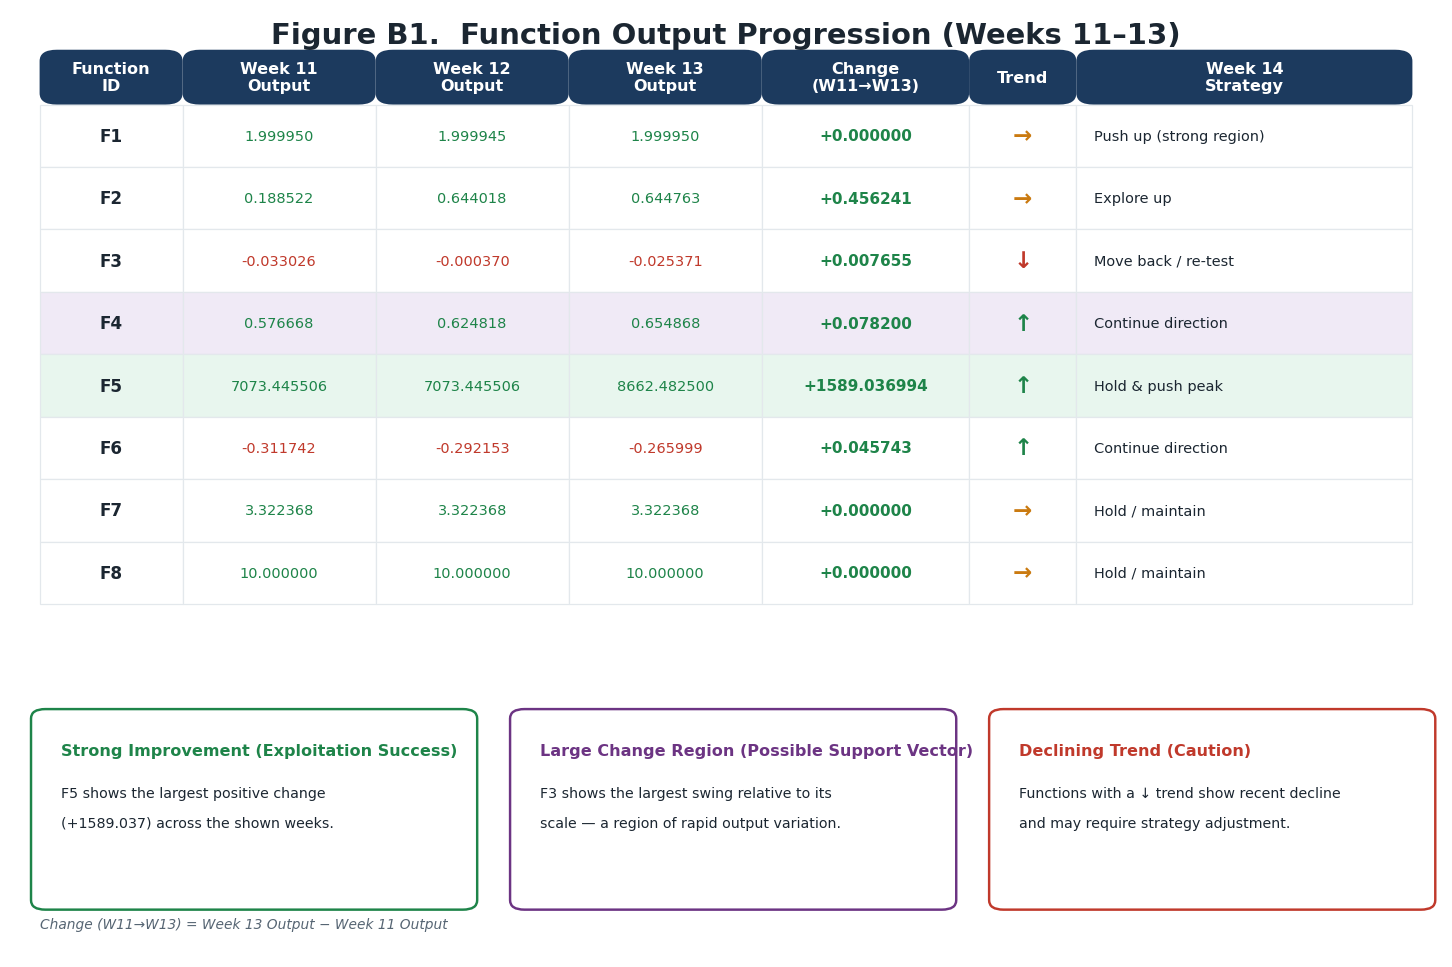

In [13]:
fig_progression(df, weekly, save="figure_B1_output_progression.png");

## 8 · Figure B2 — Function Ranking Evolution

Ranked by gain over the pre-query baseline (`RANK_METRIC`). Pass `metric="raw"` to reproduce the original output-based ranking.

In [14]:
# ───────────────────────── FIGURE B2: ranking evolution ─────────────────────────
def fig_ranking_evolution(weekly, init_best, metric=RANK_METRIC, save=None):
    show = shown_weeks(weekly)
    a, b = show[0], show[-1]
    k = len(show)
    fig = plt.figure(figsize=(13.5, 8.8))
    ax = fig.add_axes([0, 0, 1, 1]); ax.axis("off"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.text(0.5, 0.97, f"Figure B2.  Function Ranking Evolution Across Weeks {a}–{b}",
            ha="center", fontsize=18.5, fontweight="bold", color=INK)
    basis = {"raw": "ranked by raw output",
             "abs_improvement": "ranked by absolute gain over the Week-0 baseline",
             "rel_improvement": "ranked by % gain over the Week-0 baseline"}[metric]
    ax.text(0.5, 0.935, f"How the optimisation landscape evolved as evidence accumulated — {basis}",
            ha="center", fontsize=11, style="italic", color=NAVY2)

    gap = 0.025
    panel_w = (0.94 - gap * (k - 1)) / k
    x0 = 0.03
    top = 0.85; hh = 0.06; rh = 0.052
    medal = {1: GOLD, 2: SILVER, 3: BRONZE}
    val_label = metric_label(metric)

    for pi, wkn in enumerate(show):
        px = x0 + pi * (panel_w + gap)
        col = PANEL_COLORS[pi % len(PANEL_COLORS)]
        sub = "Earliest shown" if pi == 0 else ("Latest round" if pi == k - 1 else "Refining")
        _round_header(ax, px, top, panel_w, hh, f"WEEK {wkn}\n{sub}", fc=col, fs=11)
        cwx = [px, px + panel_w * 0.22, px + panel_w * 0.55]
        cww = [panel_w * 0.22, panel_w * 0.33, panel_w * 0.45]
        for cx, cw, t in zip(cwx, cww, ["RANK", "FN", val_label]):
            _cell(ax, cx, top - 0.05, cw, 0.05, t, fc="#eef2f6", tc=NAVY, fs=8, weight="bold")
        ranked = rank_for_week(weekly, init_best, wkn, metric)
        for ri, f in enumerate(ranked):
            y = top - 0.05 - (ri + 1) * rh
            val = metric_value(weekly, init_best, f, wkn, metric)
            band = "#f7f9fb" if ri % 2 else "white"
            _cell(ax, cwx[0], y, cww[0], rh, "", fc=band)
            if ri + 1 in medal:
                ax.add_patch(Circle((cwx[0] + cww[0] / 2, y + rh / 2), 0.013,
                             fc=medal[ri + 1], ec="white", lw=1, zorder=4))
                ax.text(cwx[0] + cww[0] / 2, y + rh / 2, str(ri + 1), ha="center", va="center",
                        fontsize=8, fontweight="bold", color="white", zorder=5)
            else:
                ax.text(cwx[0] + cww[0] / 2, y + rh / 2, str(ri + 1), ha="center", va="center",
                        fontsize=9.5, color=INK, zorder=3)
            _cell(ax, cwx[1], y, cww[1], rh, f"F{f}", fc=band, tc=NAVY, weight="bold", fs=10.5)
            vcol = GREEN if val > 0 else (RED if val < 0 else GREY)
            _cell(ax, cwx[2], y, cww[2], rh, metric_format(val, metric), fc=band, tc=vcol, fs=9.5, weight="bold")
        if pi < k - 1:
            ax_x = px + panel_w + gap / 2
            ax.add_patch(FancyArrow(ax_x - 0.012, top + hh / 2, 0.024, 0, width=0.006,
                         head_width=0.022, head_length=0.012, fc=NAVY, ec="none",
                         length_includes_head=True))

    by = 0.05; bh = 0.30
    last_rank = rank_for_week(weekly, init_best, b, metric)
    first_rank = rank_for_week(weekly, init_best, a, metric)
    top_fn, bot_fn = last_rank[0], last_rank[-1]
    movers = [f"F{f}" for f in range(1, 9)
              if abs(first_rank.index(f) - last_rank.index(f)) >= 2]
    obs = [
        f"F{top_fn} leads on {basis.replace('ranked by ', '')}.",
        f"F{bot_fn} sits at the bottom on this metric.",
        ("Biggest rank movers: " + ", ".join(movers)) if movers else "Rankings are largely stable across the shown weeks.",
        "Ranking by gain-over-baseline prevents large-scale functions topping the list on magnitude alone.",
    ]
    ax.add_patch(FancyBboxPatch((0.03, by), 0.46, bh, boxstyle="round,pad=0.008,rounding_size=0.01",
                 fc="#eef3fa", ec="#cfdcec", lw=1.2))
    ax.text(0.26, by + bh - 0.03, "KEY OBSERVATIONS", ha="center", color=NAVY, fontweight="bold", fontsize=12)
    for i, o in enumerate(obs):
        yy = by + bh - 0.075 - i * 0.052
        ax.add_patch(Circle((0.06, yy + 0.012), 0.009, fc=NAVY, ec="none"))
        _wrapped(ax, 0.078, yy + 0.024, o, width_chars=52, fs=9.4, leading=0.028)

    ax.add_patch(FancyBboxPatch((0.51, by), 0.46, bh, boxstyle="round,pad=0.008,rounding_size=0.01",
                 fc="#fcf6e8", ec="#ecdcb0", lw=1.2))
    ax.text(0.74, by + bh - 0.03, "INTERPRETATION", ha="center", color=ORANGE, fontweight="bold", fontsize=12)
    interp = (f"Because functions are scored on improvement over their own pre-query "
              f"baseline (Week-0 best), a function only ranks highly by making real "
              f"progress. F{top_fn} shows the strongest gain; F{bot_fn} the weakest. "
              f"Functions that never beat their baseline score 0 and drop down the list.")
    _wrapped(ax, 0.535, by + bh - 0.08, interp, width_chars=56, fs=9.7, leading=0.036)

    if save:
        fig.savefig(save, bbox_inches="tight", facecolor="white")
    return fig

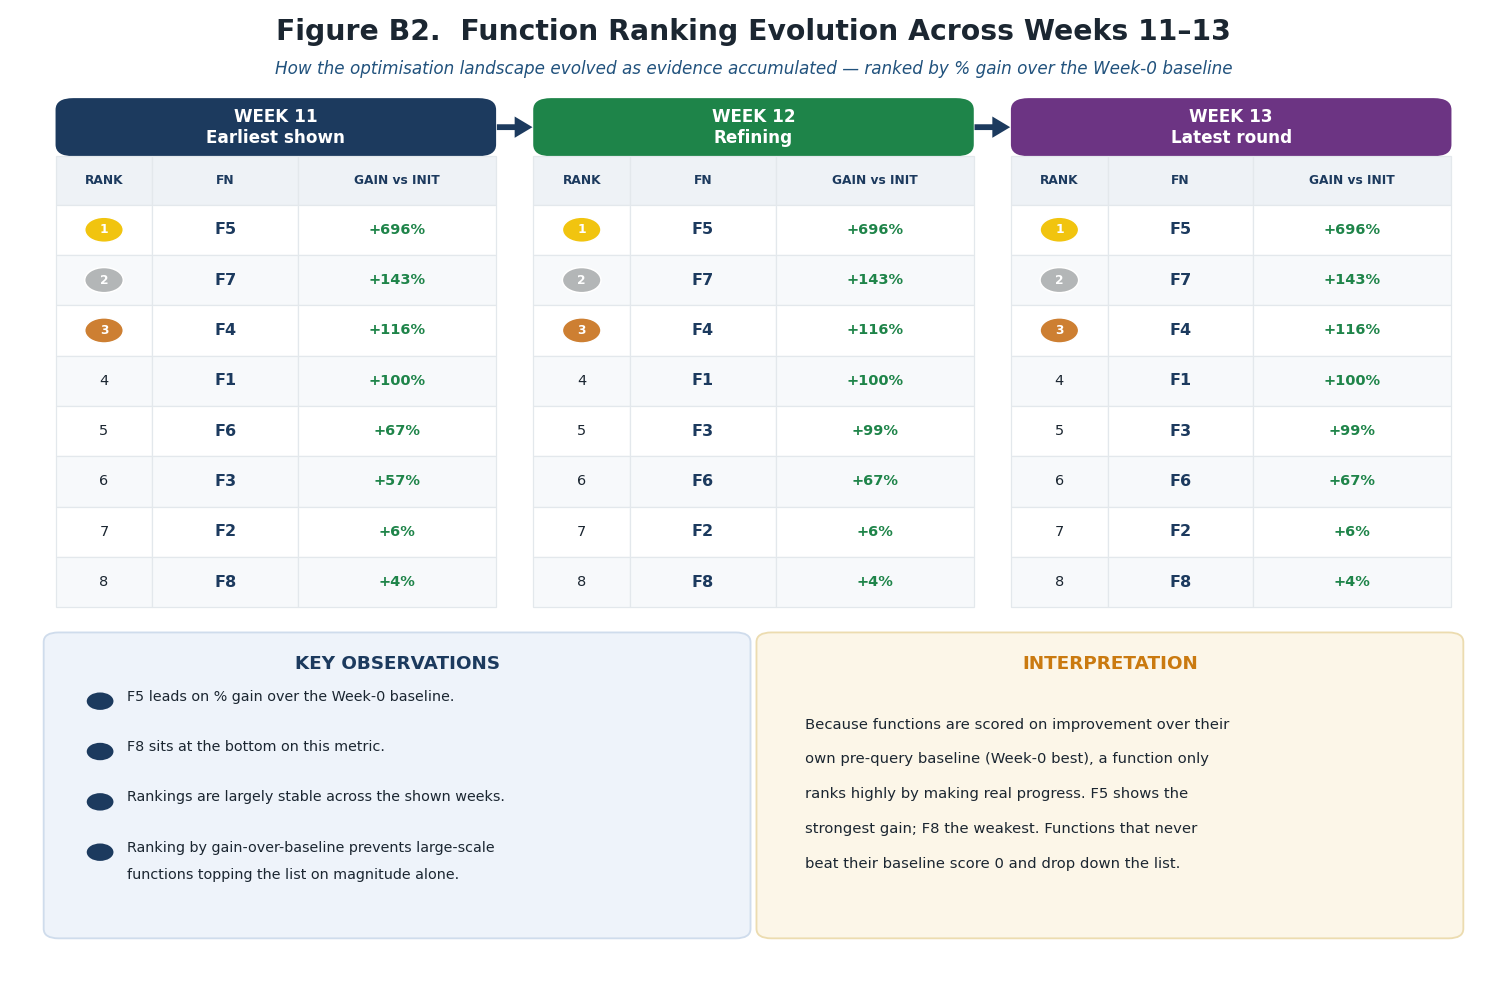

In [15]:
fig_ranking_evolution(weekly, init_best, save="figure_B2_ranking_evolution.png");

## 9 · Figure B3 — Performance & Priority Dashboard

In [16]:
# ───────────────────────── FIGURE B3: dashboard ─────────────────────────
def fig_dashboard(df, weekly, save=None):
    wk = df.iloc[0]["week_nums"]; a, b = wk[0], wk[-1]; nwk = len(wk)
    nxt = next_week_label(weekly)
    fig = plt.figure(figsize=(15.5, 10.2))
    gs = gridspec.GridSpec(3, 2, height_ratios=[0.05, 1.05, 0.78],
                           width_ratios=[1.05, 0.95], hspace=0.18, wspace=0.08,
                           left=0.015, right=0.985, top=0.99, bottom=0.02)
    fig.text(0.5, 0.975, f"Figure B3.  Function Performance Summary and {nxt} Priorities",
             ha="center", fontsize=19, fontweight="bold", color=INK)
    fig.text(0.5, 0.948, "Combining output levels, trends, gain-over-baseline and decision-matrix "
             "positions to set next-round query priorities.",
             ha="center", fontsize=11.5, style="italic", color=NAVY2)

    # ---- Panel A ----
    axA = fig.add_subplot(gs[1, 0]); axA.axis("off"); axA.set_xlim(0, 1); axA.set_ylim(0, 1)
    _round_header(axA, 0.0, 0.93, 1.0, 0.06, f"A.  PERFORMANCE SUMMARY (WEEKS {a}–{b})", fs=12)
    cols = ["Function"] + [f"W{w}" for w in wk] + ["Change", "vs Init", "Trend", "Conf.", "Matrix"]
    wkw = 0.315 / nwk
    cw = [0.135] + [wkw] * nwk + [0.115, 0.10, 0.06, 0.07, 0.115]
    cx = [0.0]
    for w in cw: cx.append(cx[-1] + w)
    top = 0.86; hh = 0.06; rh = 0.083
    for i in range(len(cols)):
        _cell(axA, cx[i], top, cw[i], hh, cols[i], fc="#eef2f6", tc=NAVY, fs=9, weight="bold")
    d = df.sort_values("f").reset_index(drop=True)
    qshort = {"High-Confidence Exploitation": "Top-Right", "Exploit": "Top-Left",
              "Monitor / Refine": "Bot-Right", "Explore": "Bot-Left"}
    for ri, r in d.iterrows():
        y = top - (ri + 1) * rh
        band = "white" if ri % 2 else "#f7f9fb"
        _cell(axA, cx[0], y, cw[0], rh, r["name"], fc=band, weight="bold", tc=NAVY, fs=10)
        for k in range(nwk):
            v = r["weeks"][k]
            _cell(axA, cx[k + 1], y, cw[k + 1], rh, f"{v:.3g}", fc=band,
                  tc=(GREEN if v > 0 else RED), fs=8.5)
        i0 = nwk + 1
        _cell(axA, cx[i0], y, cw[i0], rh, _signed(r["change"], 3), fc=band,
              tc=(GREEN if r["change"] >= 0 else RED), fs=8.5)
        gcol = GREEN if r["rel_gain"] > 1e-9 else (RED if r["rel_gain"] < -1e-9 else GREY)
        _cell(axA, cx[i0 + 1], y, cw[i0 + 1], rh, f"{r['rel_gain']:+.0f}%", fc=band, tc=gcol, fs=8.5, weight="bold")
        _cell(axA, cx[i0 + 2], y, cw[i0 + 2], rh, r["trend"], fc=band, tc=r["trend_col"], fs=14, weight="bold")
        _cell(axA, cx[i0 + 3], y, cw[i0 + 3], rh, f"{r['conf']:.2f}", fc=band, fs=9)
        _cell(axA, cx[i0 + 4], y, cw[i0 + 4], rh, qshort[r["quadrant"]], fc=band, fs=8, tc=NAVY2)

    # ---- Panel B ----
    axB = fig.add_subplot(gs[1, 1])
    med = df["med_output"].iloc[0]
    fcs = [{"High-Confidence Exploitation": NAVY2, "Exploit": "#2e86de",
            "Monitor / Refine": ORANGE, "Explore": "#16a085"}[q] for q in df["quadrant"]]
    axB.set_yscale("symlog", linthresh=1.0)
    axB.scatter(df["conf"], df["w_last"], s=180, c=fcs, edgecolors="white", linewidths=1.5, zorder=5)
    for _, r in df.iterrows():
        axB.annotate(r["name"], (r["conf"], r["w_last"]), textcoords="offset points",
                     xytext=(9, 4), fontsize=10, fontweight="bold", color=INK, zorder=6)
    axB.axvline(0.5, ls="--", color="#95a5a6", lw=1)
    axB.axhline(med, ls="--", color="#95a5a6", lw=1)
    axB.set_xlim(0.05, 1.0)
    axB.set_xlabel("Confidence / trend stability  (lower → higher)", fontsize=10)
    axB.set_ylabel(f"Output quality (Week {b}, symlog — higher is better)", fontsize=10)
    axB.set_title(f"B.  WEEK {b} DECISION MATRIX OVERVIEW", fontsize=12, fontweight="bold",
                  color="white", backgroundcolor=NAVY, pad=10)
    axB.grid(alpha=0.25)
    yl = axB.get_ylim()
    axB.text(0.08, yl[1] * 0.6, "Exploit\n(high output,\nlow conf.)", fontsize=9, color="#2e86de", fontweight="bold", va="top")
    axB.text(0.97, yl[1] * 0.6, "High-Confidence\nExploitation", fontsize=9, color=NAVY2, fontweight="bold", ha="right", va="top")
    axB.text(0.08, yl[0] * 0.6, "Explore\n(low output,\nlow conf.)", fontsize=9, color="#16a085", fontweight="bold", va="bottom")
    axB.text(0.97, yl[0] * 0.6, "Monitor / Refine", fontsize=9, color=ORANGE, fontweight="bold", ha="right", va="bottom")

    # ---- Panel C ----
    axC = fig.add_subplot(gs[2, 0]); axC.axis("off"); axC.set_xlim(0, 1); axC.set_ylim(0, 1)
    _round_header(axC, 0.0, 0.9, 1.0, 0.09, "C.  KEY INSIGHTS", fc=GREEN, fs=12)
    top_gain = df.loc[df["rel_gain"].idxmax()]
    most_conf = df.loc[df["conf"].idxmax()]
    no_improve = df[~df["improved"]]["name"].tolist()
    decliners = df[df["trend"] == "↓"]["name"].tolist()
    low = df[~df["high_output"]]["name"].tolist()
    insights = [
        f"{top_gain['name']} has the largest gain over baseline ({top_gain['rel_gain']:+.0f}%) — top exploitation target.",
        f"{most_conf['name']} has the highest confidence ({most_conf['conf']:.2f}) — stable region.",
        f"No gain over baseline yet: {', '.join(no_improve) if no_improve else 'none'}.",
        f"Declining trends ({', '.join(decliners) if decliners else 'none'}) need re-testing.",
        f"Low-output functions ({', '.join(low)}) need continued exploration.",
    ]
    for i, t in enumerate(insights):
        yy = 0.78 - i * 0.155
        axC.add_patch(Circle((0.03, yy), 0.022, fc=GREEN, ec="none"))
        axC.text(0.03, yy, "✓", ha="center", va="center", color="white", fontsize=10, fontweight="bold")
        _wrapped(axC, 0.07, yy + 0.03, t, width_chars=78, fs=9.6, leading=0.05)

    # ---- Panels D + E ----
    axDE = fig.add_subplot(gs[2, 1]); axDE.axis("off"); axDE.set_xlim(0, 1); axDE.set_ylim(0, 1)
    _round_header(axDE, 0.0, 0.9, 0.52, 0.09, f"D.  {nxt.upper()} PRIORITY RANKING", fc=PURPLE, fs=10.5)
    hw = [0.09, 0.09, 0.34]; hx = [0.0, 0.09, 0.18]
    for cxx, cww, t in zip(hx, hw, ["Rank", "Fn", "Priority"]):
        _cell(axDE, cxx, 0.82, cww, 0.06, t, fc="#efeaf6", tc=PURPLE, fs=8.5, weight="bold")
    pcolours = {"Exploit": "#eaf4ec", "Exploit / Maintain": "#eef3fa",
                "Monitor & Refine": "#fdf3e6", "Explore": "#f3eef8"}
    for ri, r in df.iterrows():
        y = 0.82 - (ri + 1) * 0.073
        band = pcolours.get(r["priority_type"], "white")
        _cell(axDE, hx[0], y, hw[0], 0.073, str(r["rank"]), fc=band, fs=9)
        _cell(axDE, hx[1], y, hw[1], 0.073, r["name"], fc=band, tc=NAVY, weight="bold", fs=9.5)
        _cell(axDE, hx[2], y, hw[2], 0.073, r["priority_type"], fc=band, ha="left", fs=8.3)

    _round_header(axDE, 0.56, 0.9, 0.44, 0.09, f"E.  {nxt.upper()} STRATEGY", fc=NAVY, fs=10.5)
    exploit = df[df["grp"] == 0]["name"].tolist()
    monitor = df[df["grp"] == 1]["name"].tolist()
    explore = df[df["grp"] == 2]["name"].tolist()
    blocks = [
        ("Focus exploitation", f"Prioritise {', '.join(exploit) or '—'} to maximise gains in strong regions.", "#2e86de"),
        ("Monitor & refine", f"Re-test {', '.join(monitor) or '—'} to recover or confirm trends.", ORANGE),
        ("Explore new regions", f"Allocate queries to {', '.join(explore) or '—'} to find untapped areas.", GREEN),
    ]
    for i, (title, body, col) in enumerate(blocks):
        yy = 0.78 - i * 0.235
        axDE.add_patch(Circle((0.585, yy - 0.006), 0.012, fc=col, ec="none"))
        axDE.text(0.61, yy, title, fontsize=9.8, fontweight="bold", color=col, va="top")
        _wrapped(axDE, 0.57, yy - 0.05, body, width_chars=40, fs=8.7, leading=0.034)

    fig.text(0.5, 0.012,
             f"Overall: combining output level, trend and gain-over-baseline balances exploitation "
             f"of proven regions ({', '.join(exploit)}) with exploration of uncertain ones "
             f"({', '.join(explore)}) for {nxt}.",
             ha="center", fontsize=9.6, style="italic", color=GREY,
             bbox=dict(boxstyle="round,pad=0.5", fc="#fffbe9", ec="#f0d878"))
    if save:
        fig.savefig(save, bbox_inches="tight", facecolor="white")
    return fig

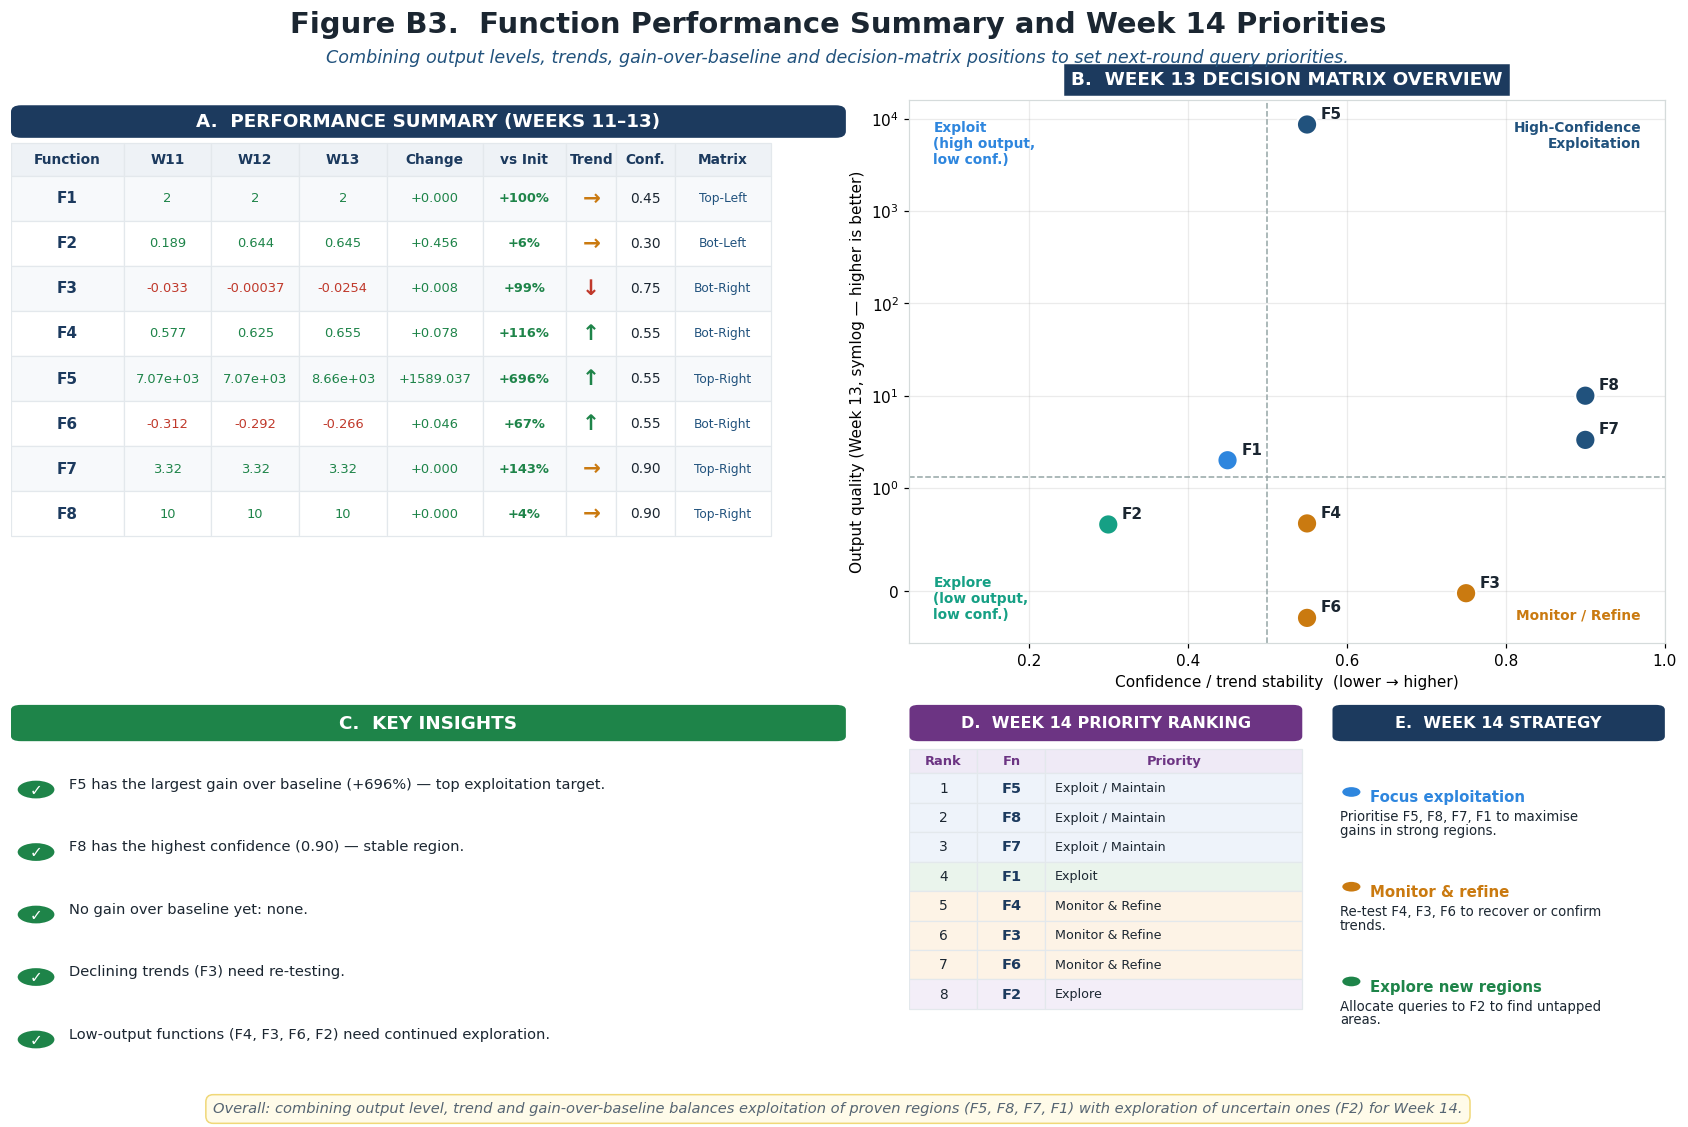

In [17]:
fig_dashboard(df, weekly, save="figure_B3_dashboard.png");

## 10 · Figure B4 — Function Scoreboard

Best-ever **normalised score** `(best − baseline) / (ceiling − baseline)`, clipped to 0–1, using your estimated true maxima in `CEILINGS`. Whiskers show the score range implied by each ceiling's `lo`/`hi` bounds (wider = lower confidence). Drop `ceilings=` to fall back to the scale-fair % gain over baseline.

In [18]:
def fig_scoreboard(weekly, init_best, ceilings=None, save=None):
    T=n_total_weeks(weekly)
    rb={f:running_best_upto(weekly,init_best,f,T) for f in range(1,9)}
    is_norm=ceilings is not None
    def _cval(f): v=ceilings[f]; return v["c"] if isinstance(v,dict) else v
    def _score(f,c):
        d=c-init_best[f]
        return np.nan if abs(d)<1e-12 else float(np.clip((rb[f]-init_best[f])/d,0.0,1.0))
    vals,bands,confs={},{},{}
    for f in range(1,9):
        if is_norm:
            vals[f]=_score(f,_cval(f)); v=ceilings[f]
            if isinstance(v,dict):
                confs[f]=v.get("conf","")
                if "lo" in v and "hi" in v:
                    ss=[s for s in (_score(f,v["lo"]),_score(f,v["hi"]),vals[f]) if np.isfinite(s)]
                    if ss and max(ss)-min(ss)>0.005: bands[f]=(min(ss),max(ss))
        else:
            vals[f]=rel_gain_pct(rb[f],init_best[f],_obs_range(weekly,init_best,f))
    order=sorted(range(1,9),key=lambda f:np.nan_to_num(vals[f],nan=-1)); ranked=list(reversed(order))
    vmax=1.0 if is_norm else (max(vals.values()) or 1.0)
    fmt=(lambda v:"—" if not np.isfinite(v) else f"{v:.2f}") if is_norm else (lambda v:f"{v:+.0f}%")
    unit="normalised score (0–1, vs estimated true max)" if is_norm else "% gain over the Week-0 baseline"

    W,H=15.6,9.4; YT=100*H/W
    fig=plt.figure(figsize=(W,H));fig.patch.set_facecolor("white")
    bg=fig.add_axes([0,0,1,1]);bg.set_xlim(0,100);bg.set_ylim(0,YT);bg.axis("off")
    frac=lambda x,y,w,h:[x/100,y/YT,w/100,h/YT]
    _ipanel(bg,2,53.2,96,5.6,fc=INFO_NAVY,ec="none",r=1.3)
    bg.text(50,56.3,"FIGURE B4  ·  FUNCTION SCOREBOARD",ha="center",va="center",color="white",fontsize=21,fontweight="bold")
    bg.text(50,54.0,f"Best-ever {unit} for each of the eight unknown functions",ha="center",va="center",color="#f4b942",fontsize=11.5,fontstyle="italic")
    _ipanel(bg,2,12.5,61,39.3);_ipanel(bg,65.5,12.5,32.5,39.3)
    _ipill(bg,20.5,49.2,33,2.7,"Performance by Function",INFO_BLUE,fs=12.5)
    _ipill(bg,81.5,49.2,22,2.7,"KEY INSIGHTS",INFO_GREEN,fs=12.5)

    ax=fig.add_axes(frac(8.5,15.5,48,30.5));ax.set_facecolor("none");y=np.arange(8)
    for s in ax.spines.values(): s.set_visible(False)
    ticks=np.linspace(0,vmax,5)
    for gx in ticks[1:]: ax.axvline(gx,color="#e7edf6",lw=1.1,zorder=0)
    ax.barh(y,vmax,height=0.52,color=TRACK,zorder=1)
    ax.barh(y,[np.nan_to_num(vals[f]) for f in order],height=0.52,color=[FUNCTION_COLORS[f] for f in order],zorder=2)
    for i,f in enumerate(order):
        if f in bands:
            lo,hi=bands[f]
            ax.plot([lo,hi],[i,i],color="#33405a",lw=1.5,zorder=4,solid_capstyle="butt")
            for xc in (lo,hi): ax.plot([xc,xc],[i-0.13,i+0.13],color="#33405a",lw=1.5,zorder=4)
        lx=(bands[f][1] if f in bands else (vals[f] if np.isfinite(vals[f]) else 0))
        ax.text(lx+vmax*0.022,i,fmt(vals[f]),va="center",ha="left",
                fontsize=10.5,fontweight="bold",color=FUNCTION_COLORS[f])
    ax.set_xlim(0,vmax*1.16);ax.set_ylim(-0.6,7.4)
    ax.set_yticks(y);ax.set_yticklabels([f"F{f}" for f in order],fontsize=12,fontweight="bold")
    for t,f in zip(ax.get_yticklabels(),order): t.set_color(FUNCTION_COLORS[f])
    ax.set_xticks(ticks);ax.tick_params(length=0,labelsize=9)
    ax.set_xlabel(unit,fontsize=10,color=MUTED,labelpad=7)

    best,worst=ranked[0],ranked[-1]; rawmax=max(rb,key=rb.get)
    if is_norm:
        solved=[f for f in ranked if np.isfinite(vals[f]) and vals[f]>=0.995]
        n_high=sum(np.isfinite(vals[f]) and vals[f]>=0.90 for f in range(1,9))
        insights=[
            (best,(f"F{solved[0]} & F{solved[1]} effectively solved" if len(solved)>=2 else f"F{best} leads"),
                  (f"Both at a normalised score of 1.00 — at their known true max." if len(solved)>=2 else f"Top of the table at {fmt(vals[best])}.")),
            (best,f"{n_high} of 8 are ≥ 0.90",f"Close to their estimated ceilings; little headroom left there."),
            (rawmax,f"F{rawmax} leads raw output",f"But sits at only {vals[rawmax]:.0%} of its (uncertain) ceiling — the clearest headroom."),
            (worst,f"F{worst} lowest at {fmt(vals[worst])}",f"Whiskers show ceiling uncertainty; wider = lower confidence in the score."),
        ]
    else:
        n_imp=sum(v>1e-9 for v in vals.values());zero=[f"F{f}" for f in ranked if vals[f]<=1e-9]
        insights=[(best,f"F{best} leads the field",f"Largest result at {fmt(vals[best])}."),
                  (ranked[1],f"F{ranked[1]} follows",f"Second at {fmt(vals[ranked[1]])}."),
                  (worst,f"F{worst} has the most headroom",f"Lowest at {fmt(vals[worst])}."),
                  (best,f"{n_imp} of 8 improved",("No gain yet: "+", ".join(zero)) if zero else "All beat baseline.")]
    iy=44.5
    for f,lead,detail in insights:
        bg.add_patch(FancyBboxPatch((67.4,iy-0.55),1.1,1.1,boxstyle="round,pad=0,rounding_size=0.35",fc=FUNCTION_COLORS[f],ec="none",zorder=4))
        bg.text(69.4,iy,lead,fontsize=10.5,fontweight="bold",va="center",color=INK,zorder=4)
        bg.text(69.4,iy-1.55,textwrap.fill(detail,37),fontsize=8.6,va="top",color="#41506a",zorder=4,linespacing=1.25)
        iy-=7.7

    def arrow(f): return "\u2191" if (np.isfinite(vals[f]) and vals[f]>1e-9) else "\u2192"
    gap,x0,x1=1.2,2.0,98.0;cw=(x1-x0-gap*7)/8
    for i in range(8):
        f=i+1;cxs=x0+i*(cw+gap);c=FUNCTION_COLORS[f]
        _ipanel(bg,cxs,5.4,cw,6.1,fc=_tint(c,0.86),ec=_tint(c,0.55),lw=1.4,r=0.8);cc=cxs+cw/2
        bg.text(cc,10.5,f"F{f}",ha="center",color=c,fontsize=13,fontweight="bold")
        bg.text(cc,8.7,fmt(vals[f]),ha="center",color=INK,fontsize=12.5,fontweight="bold")
        tag=f"{arrow(f)} {STATUS_SHORT[FUNCTION_META[f]['status']]}"
        if confs.get(f): tag+=f" · {confs[f]}"
        bg.text(cc,6.55,tag,ha="center",color=c,fontsize=7.8,fontweight="bold")

    _ipanel(bg,2,0.7,96,3.4,fc=INFO_NAVY,ec="none",r=1.0)
    foot=(f"Scored against each function's estimated true max (solved: F7, F8). "
          f"F{rawmax} dominates raw output yet is ~{vals[rawmax]:.0%} of the way there; whiskers mark ceiling uncertainty."
          if is_norm else
          f"Scoreboard ranks functions by {unit}.")
    bg.text(50,2.4,foot,ha="center",va="center",color="#dfe7f5",fontsize=10.2,zorder=4)
    if save: fig.savefig(save,dpi=130,bbox_inches="tight",facecolor="white",pad_inches=0.12)
    return fig


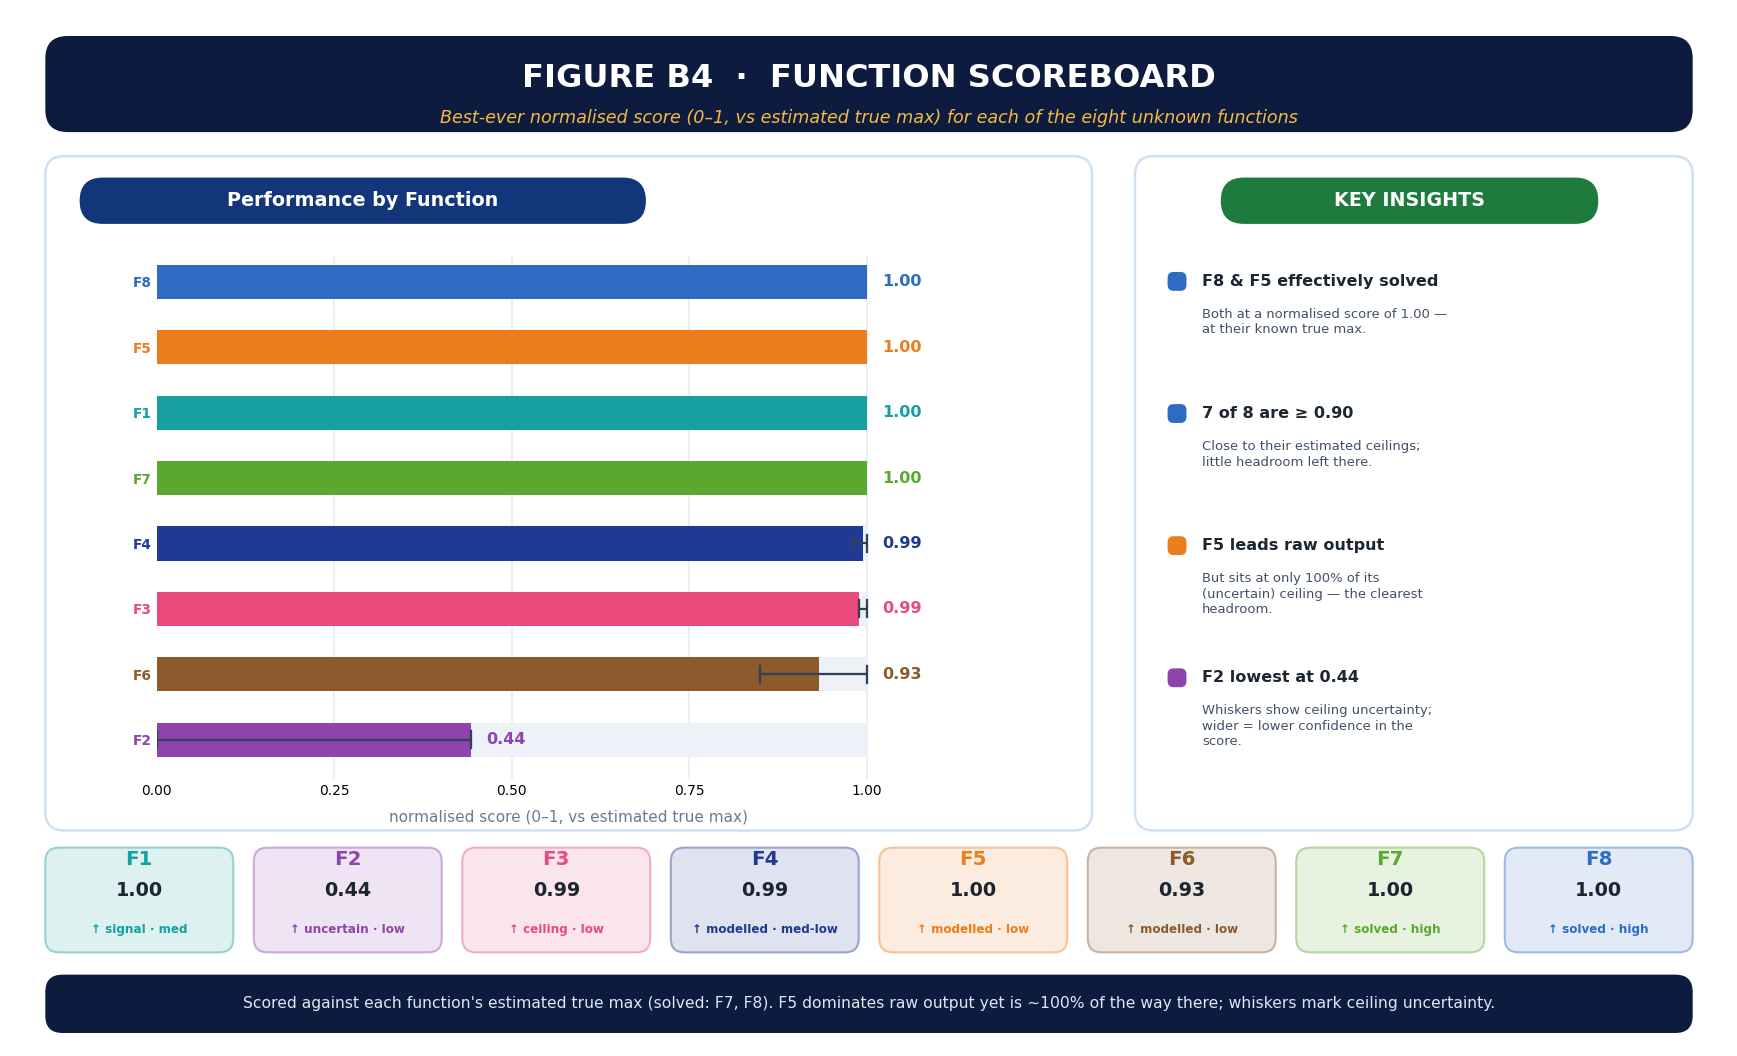

In [19]:
fig_scoreboard(weekly, init_best, ceilings=CEILINGS, save="figure_B4_scoreboard.png");

## 11 · Figure B5 — Function Output Trajectories

Every function's raw output per round on one chart. `yscale="symlog"` (default) keeps large- and small-scale functions both visible — the same reasoning as the dashboard's decision matrix; use `"linear"` for a raw axis. The shaded band is the spread across functions.

In [20]:
def fig_trajectories(weekly, init_best, yscale="symlog", save=None):
    T=n_total_weeks(weekly); x=list(range(1,T+1))
    arr=np.array([[weekly[f][w] for f in range(1,9)] for w in range(T)])  # T x 8
    W,H=15.6,9.4; YT=100*H/W
    fig=plt.figure(figsize=(W,H)); fig.patch.set_facecolor("white")
    bg=fig.add_axes([0,0,1,1]); bg.set_xlim(0,100); bg.set_ylim(0,YT); bg.axis("off")
    frac=lambda X,Y,Wd,Hd:[X/100,Y/YT,Wd/100,Hd/YT]
    _ipanel(bg,2,53.2,96,5.6,fc=INFO_NAVY,ec="none",r=1.3)
    bg.text(50,56.3,"FIGURE B5  ·  FUNCTION OUTPUT TRAJECTORIES",ha="center",va="center",
            color="white",fontsize=21,fontweight="bold")
    bg.text(50,54.0,f"Raw query output per round across Weeks 1–{T} — all eight functions together",
            ha="center",va="center",color="#f4b942",fontsize=11.5,fontstyle="italic")
    _ipanel(bg,2,12.0,61,39.8); _ipanel(bg,65.5,12.0,32.5,39.8)
    _ipill(bg,16.5,49.4,25,2.7,"Output by Round",INFO_BLUE,fs=12.5)
    _ipill(bg,81.5,49.4,22,2.7,"KEY INSIGHTS",INFO_GREEN,fs=12.5)

    ax=fig.add_axes(frac(9,16,52,29.5)); ax.set_facecolor("none")
    ax.fill_between(x,arr.min(axis=1),arr.max(axis=1),color="#e3e9f2",alpha=0.75,lw=0,zorder=0)
    for f in range(1,9):
        ax.plot(x,weekly[f],color=FUNCTION_COLORS[f],marker="o",ms=4.3,lw=2.1,zorder=3)
        ax.text(x[-1]+0.1,weekly[f][-1],f"F{f}",color=FUNCTION_COLORS[f],
                fontsize=9,fontweight="bold",va="center",zorder=4)
    ax.axhline(0,color="#9aa7bd",ls="--",lw=1,zorder=1)
    if yscale=="symlog": ax.set_yscale("symlog",linthresh=1.0)
    for s in ("top","right"): ax.spines[s].set_visible(False)
    ax.spines["left"].set_color("#cbd5e6"); ax.spines["bottom"].set_color("#cbd5e6")
    ax.set_xlim(0.7,T+0.7); ax.set_xticks(x); ax.set_xticklabels([f"W{w}" for w in x],fontsize=9.5)
    ax.tick_params(labelsize=9); ax.grid(axis="y",color="#eef2f8",lw=1)
    ax.set_xlabel("Optimisation round",fontsize=10,color=MUTED)
    ax.set_ylabel("output  (symlog scale)" if yscale=="symlog" else "output",fontsize=10,color=MUTED)

    finalv={f:weekly[f][-1] for f in range(1,9)}
    chg={f:weekly[f][-1]-weekly[f][0] for f in range(1,9)}
    top_f=max(finalv,key=finalv.get); bot_f=min(finalv,key=finalv.get); clb=max(chg,key=chg.get)
    sp0=arr[0].max()-arr[0].min(); spT=arr[-1].max()-arr[-1].min()
    insights=[
        (top_f,f"F{top_f} sits highest",f"Reaches {finalv[top_f]:.2f} by Week {T}, well clear of the field."),
        (clb,f"F{clb} climbs the most",f"Gains {chg[clb]:+.2f} from Week 1 to Week {T}."),
        (bot_f,f"F{bot_f} stays lowest",f"Ends at {finalv[bot_f]:.2f}, though its magnitude is easing."),
        (top_f,"Spread keeps widening",f"Range across functions grows from {sp0:.1f} to {spT:.1f} — the shaded band."),
    ]
    iy=44.8
    for f,lead,detail in insights:
        bg.add_patch(FancyBboxPatch((67.4,iy-0.55),1.1,1.1,boxstyle="round,pad=0,rounding_size=0.35",
                     fc=FUNCTION_COLORS[f],ec="none",zorder=4))
        bg.text(69.4,iy,lead,fontsize=11,fontweight="bold",va="center",color=INK,zorder=4)
        bg.text(69.4,iy-1.6,textwrap.fill(detail,36),fontsize=8.8,va="top",color="#41506a",zorder=4,linespacing=1.25)
        iy-=7.8

    # legend strip
    _ipanel(bg,2,5.6,96,5.4,r=0.9)
    bg.text(5,8.3,"FUNCTIONS",fontsize=9.5,fontweight="bold",color=INFO_NAVY,va="center")
    sx=15.5; step=(95-sx)/8
    for i in range(8):
        f=i+1; xx=sx+i*step
        bg.plot([xx,xx+2.2],[8.3,8.3],color=FUNCTION_COLORS[f],lw=3.2,solid_capstyle="round",zorder=4)
        bg.text(xx+2.8,8.3,f"F{f}",fontsize=9.5,fontweight="bold",color=FUNCTION_COLORS[f],va="center",zorder=4)

    _ipanel(bg,2,0.7,96,3.4,fc=INFO_NAVY,ec="none",r=1.0)
    bg.text(50,2.4,f"Output per round; the shaded band is the range across all functions (their spread). "
            f"Symlog y-axis keeps F{top_f}'s scale and the near-zero functions both legible.",
            ha="center",va="center",color="#dfe7f5",fontsize=10.5,zorder=4)
    if save: fig.savefig(save,dpi=130,bbox_inches="tight",facecolor="white",pad_inches=0.12)
    return fig


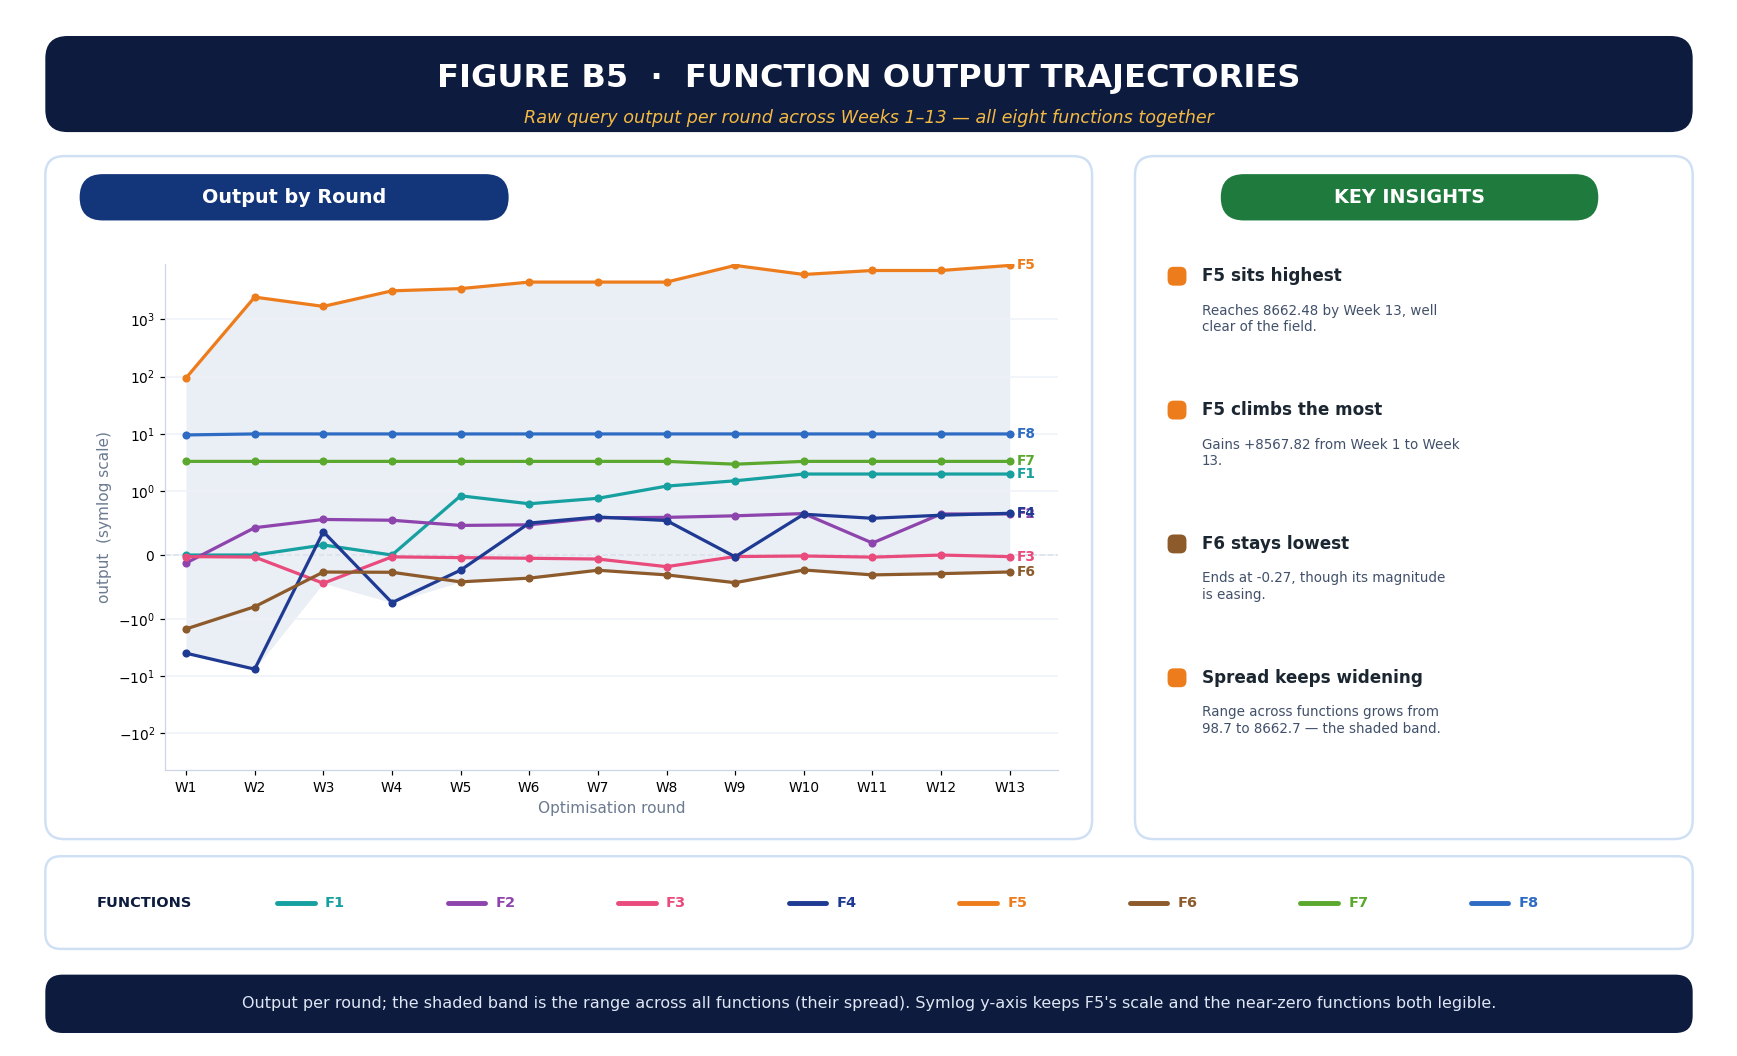

In [21]:
fig_trajectories(weekly, init_best, save="figure_B5_trajectories.png");

## 12 · Using it with your real data, week after week

1. Run `04_consolidate_data.ipynb` so **`consolidated_observations.csv`** sits next
   to this notebook (or set `BBO_CONSOLIDATED_CSV`). It must contain the Week-0
   rows (`week == 0`) — those define each function's baseline.
2. Restart & run all. The five PNGs (B1–B5) are written to the working directory.
3. **Each new round:** append the week's row in the consolidation step, re-run `04`,
   then re-run this notebook. Titles and the "next week" label update automatically.

**Customisation**
- `N_WEEKS_SHOWN` — recent rounds to display (3–5 reads well; the season runs to 13).
- `RANK_METRIC` — `"rel_improvement"` (default, scale-fair %), `"abs_improvement"`, or `"raw"`.
- `CONFIDENCE_OVERRIDE = {5: 0.40, 8: 0.85, ...}` / `STATUS_CONFIDENCE` — set confidence.
- `fig_trajectories(..., yscale=...)` — `"symlog"` (default, all functions visible) or `"linear"`.
- `fig_scoreboard(..., ceilings={f: true_max})` — % gain over baseline → 0–1 normalised score.

**Why ranking uses the pre-query baseline.** Ranking by raw Y is dominated by
scale — F5 (~2800) always wins regardless of progress. Scoring each function by
how far it has climbed above its own Week-0 best makes progress comparable across
functions of wildly different magnitudes, and stops a high-but-stagnant function
flattering itself. The decision-matrix scatter still plots raw output (on a
**symlog** axis so all eight are visible) because absolute achievement is the
honest thing to show there.